In [15]:
import jax.numpy as jnp
from jax import vmap
import math

In [16]:
def model_output(x, w):
    return jnp.dot(w, x)


In [17]:
def gaussian_likelihood(t, mean, beta):
    var = 1.0 / beta
    coeff = 1.0 / jnp.sqrt(2 * jnp.pi * var)
    exponent = - (t - mean)**2 / (2 * var)
    return coeff * jnp.exp(exponent)


In [18]:
def log_likelihood(t, mean, beta):
    var = 1.0 / beta
    return -0.5 * jnp.log(2 * jnp.pi * var) - ((t - mean) ** 2) / (2 * var)


In [19]:
x = jnp.array([1.0, 2.0])
w = jnp.array([0.5, -1.0])
t = -0.5
beta = 2.0

mean = model_output(x, w)
likelihood = gaussian_likelihood(t, mean, beta)
log_l = log_likelihood(t, mean, beta)

print("Likelihood:", likelihood)
print("Log-likelihood:", log_l)


Likelihood: 0.20755376
Log-likelihood: -1.5723649


In [20]:
X = jnp.array([
    [1.0, 0.0, 2.0],
    [0.0, -1.0, 3.0],
    [2.0, 1.0, -1.0]
])
t_values = jnp.array([1.3, 0.5, -0.7])
w = jnp.array([0.2, 0.5, -0.3])
beta = 5.0

# Vectorized prediction
def predict_log_likelihood(x, t):
    y = model_output(x, w)
    return log_likelihood(t, y, beta)

# Apply to all samples
log_likelihoods = vmap(predict_log_likelihood)(X, t_values)

# Joint log-likelihood
joint_log_likelihood = jnp.sum(log_likelihoods)

print("Log-likelihoods:", log_likelihoods)
print("Joint log-likelihood:", joint_log_likelihood)


Log-likelihoods: [-7.33922 -9.13922 -9.13922]
Joint log-likelihood: -25.61766


In [21]:
w1 = jnp.array([0.1, -0.3, 0.2])
w2 = jnp.array([-0.1, 0.5, -0.2])
X_test = jnp.array([
    [1.0, 2.0, 0.0],
    [0.0, 1.0, -1.0]
])
t_test = jnp.array([0.0, 0.6])
beta = 2.0

def compute_joint_log_likelihood(w, X, t, beta):
    def single(x, t_val):
        y = model_output(x, w)
        return log_likelihood(t_val, y, beta)
    return jnp.sum(vmap(single)(X, t))

log_l1 = compute_joint_log_likelihood(w1, X_test, t_test, beta)
log_l2 = compute_joint_log_likelihood(w2, X_test, t_test, beta)

print("Log-likelihood for w1:", log_l1)
print("Log-likelihood for w2:", log_l2)


Log-likelihood for w1: -2.60473
Log-likelihood for w2: -1.9647298


<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_28780/218243617.py:28: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(t_vals, pdf_vals, label=f'$\mathcal{{N}}(t \mid {t_mean:.2f}, {1/beta:.2f})$')
/tmp/ipykernel_28780/218243617.py:28: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(t_vals, pdf_vals, label=f'$\mathcal{{N}}(t \mid {t_mean:.2f}, {1/beta:.2f})$')


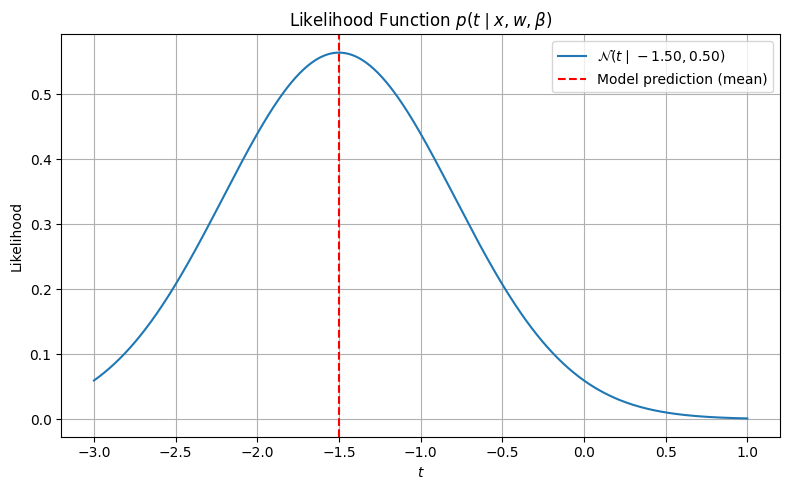

In [24]:
import jax.numpy as jnp
from jax import vmap
import matplotlib.pyplot as plt

# Define model prediction
def model_output(x, w):
    return jnp.dot(w, x)

# Define Gaussian likelihood
def gaussian_pdf(t, mean, beta):
    var = 1.0 / beta
    coeff = 1.0 / jnp.sqrt(2 * jnp.pi * var)
    exponent = - (t - mean)**2 / (2 * var)
    return coeff * jnp.exp(exponent)

# Example values
x = jnp.array([1.0, 2.0])
w = jnp.array([0.5, -1.0])
beta = 2.0
t_mean = model_output(x, w)  # this becomes the center of the distribution

# Generate t values and compute PDF
t_vals = jnp.linspace(-3, 1, 500)
pdf_vals = vmap(lambda t: gaussian_pdf(t, t_mean, beta))(t_vals)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(t_vals, pdf_vals, label=f'$\mathcal{{N}}(t \mid {t_mean:.2f}, {1/beta:.2f})$')
plt.axvline(t_mean, color='red', linestyle='--', label='Model prediction (mean)')
plt.title("Likelihood Function $p(t \\mid x, w, \\beta)$")
plt.xlabel("$t$")
plt.ylabel("Likelihood")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
